In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ecommerce_sales.csv")

In [3]:
df

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,01-01-2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,01-02-2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,01-03-2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,01-04-2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,01-05-2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,09-05-2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,09-06-2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,09-07-2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,09-08-2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38


In [18]:
# Convert mixed-format dates safely
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed'
)

# Extract month and year
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year

In [7]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(5000, 12)


In [8]:
print("\nDataset Columns:")
print(df.columns)


Dataset Columns:
Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')


In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
order_id              int64
order_date           object
customer_id           int64
product_category     object
region               object
quantity              int64
unit_price          float64
discount            float64
payment_method       object
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object


In [10]:
sns.set_style("whitegrid")

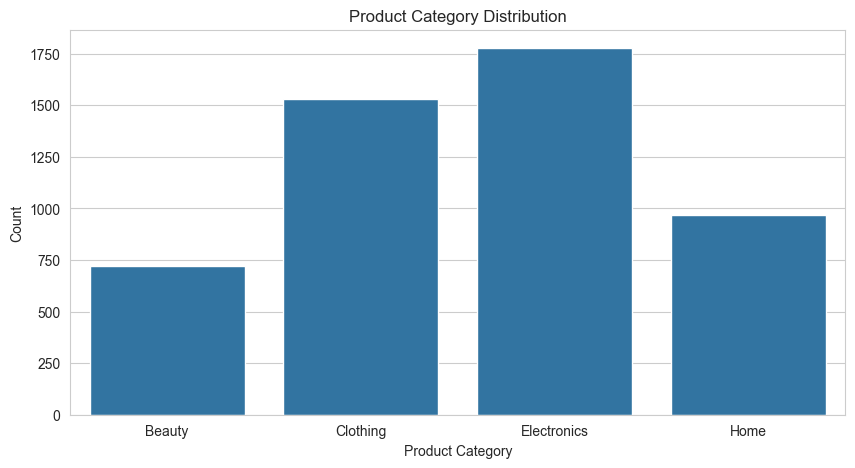

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='product_category',
    data=df
)

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.show()

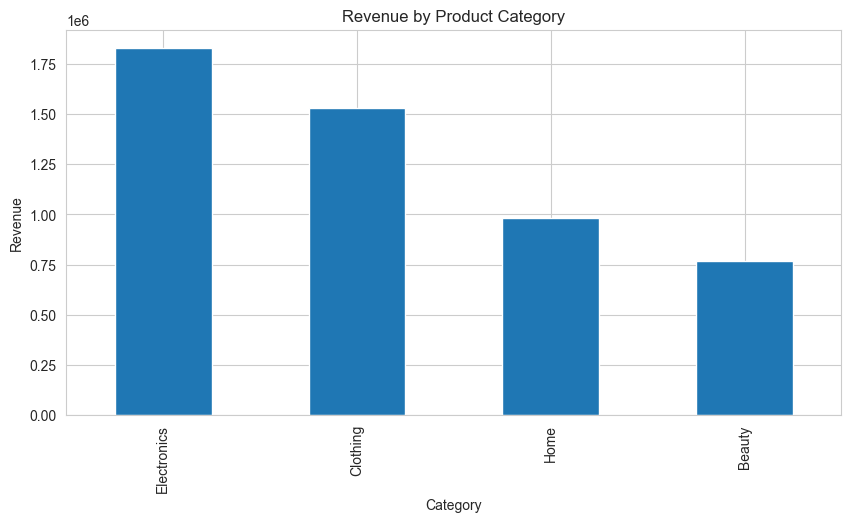

In [12]:
category_revenue = df.groupby(
    'product_category'
)['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

category_revenue.plot(
    kind='bar'
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

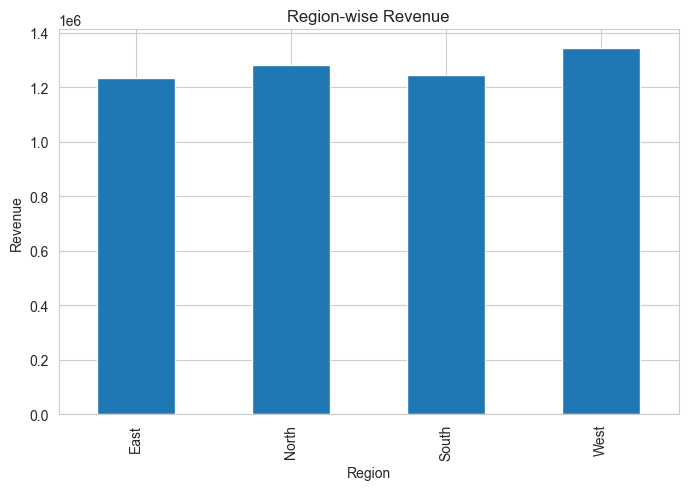

In [13]:
region_sales = df.groupby(
    'region'
)['revenue'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(
    kind='bar'
)

plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.show()

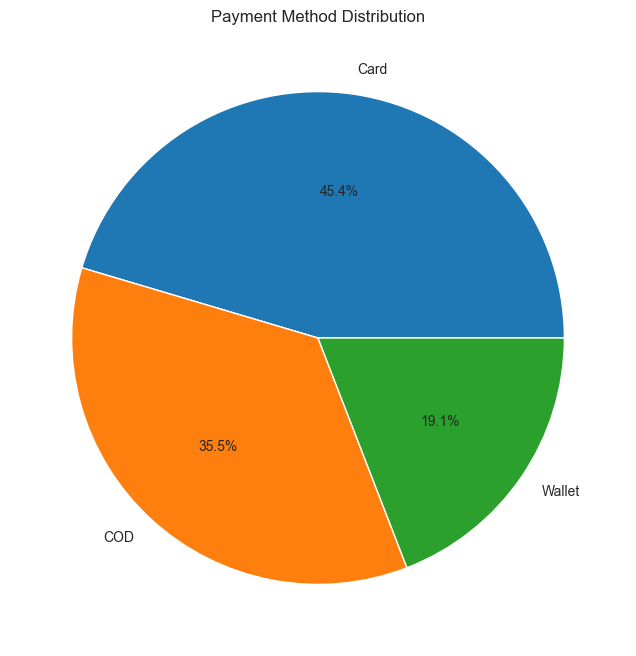

In [14]:
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8,8))

payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

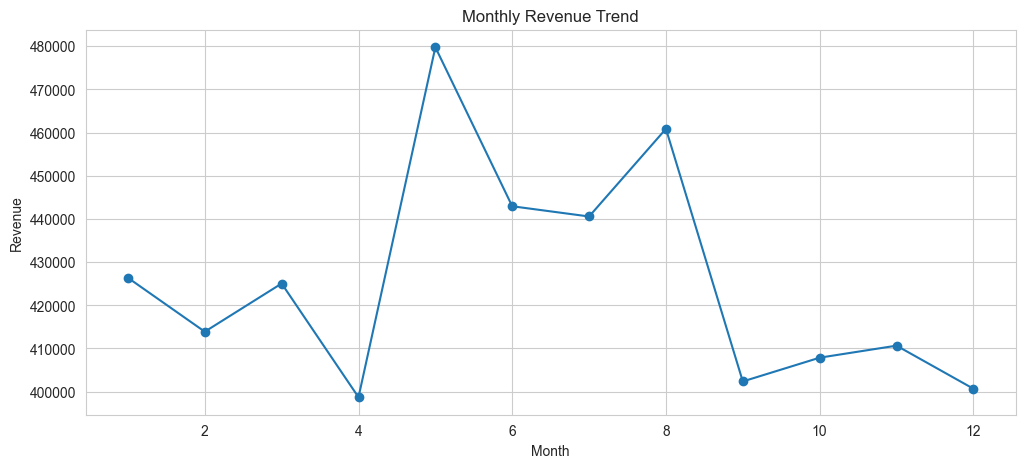

In [19]:
monthly_sales = df.groupby(
    'month'
)['revenue'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()



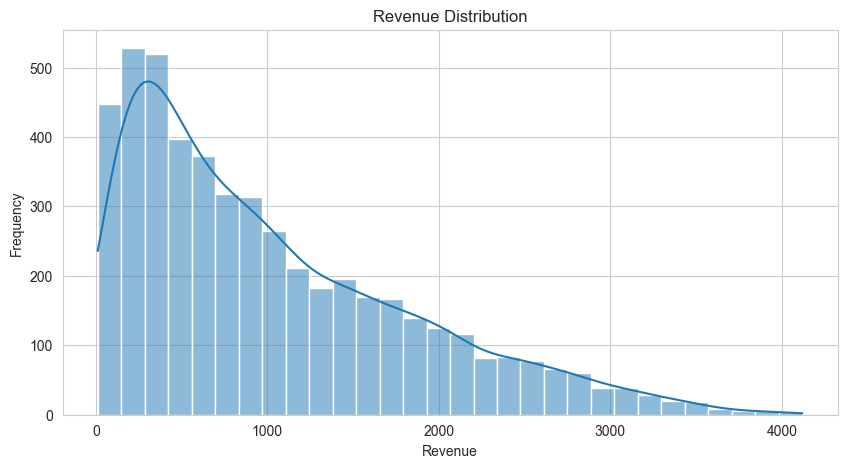

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['revenue'],
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

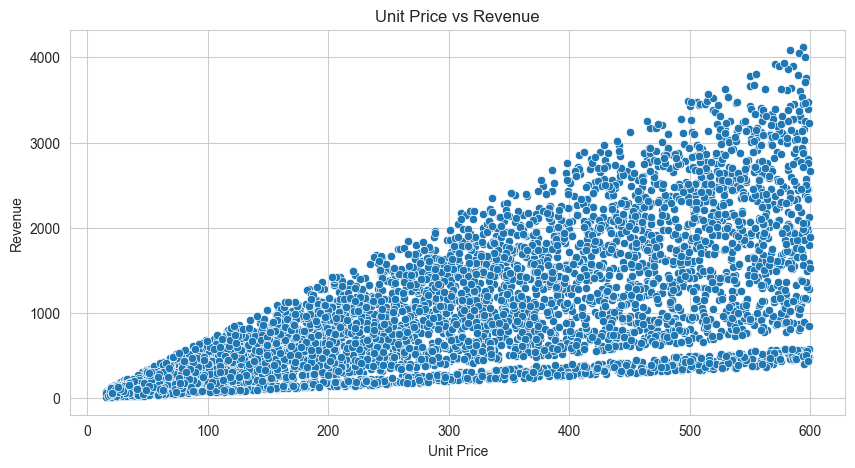

In [21]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='unit_price',
    y='revenue',
    data=df
)

plt.title("Unit Price vs Revenue")
plt.xlabel("Unit Price")
plt.ylabel("Revenue")

plt.show()

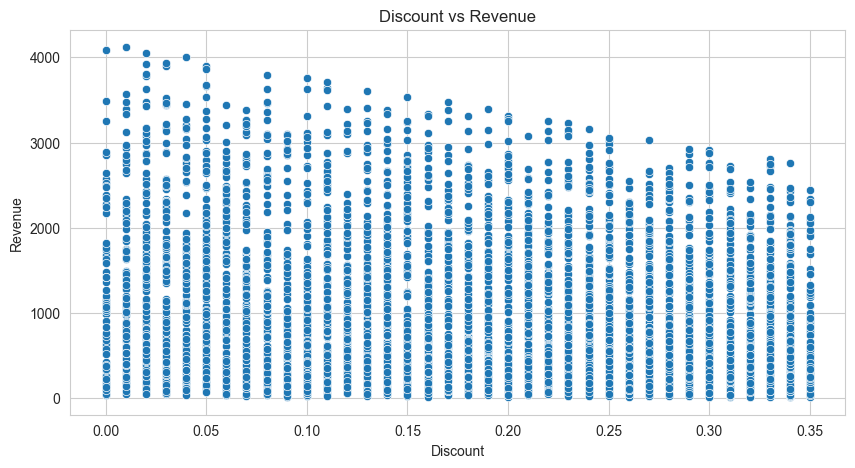

In [22]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='discount',
    y='revenue',
    data=df
)

plt.title("Discount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")

plt.show()

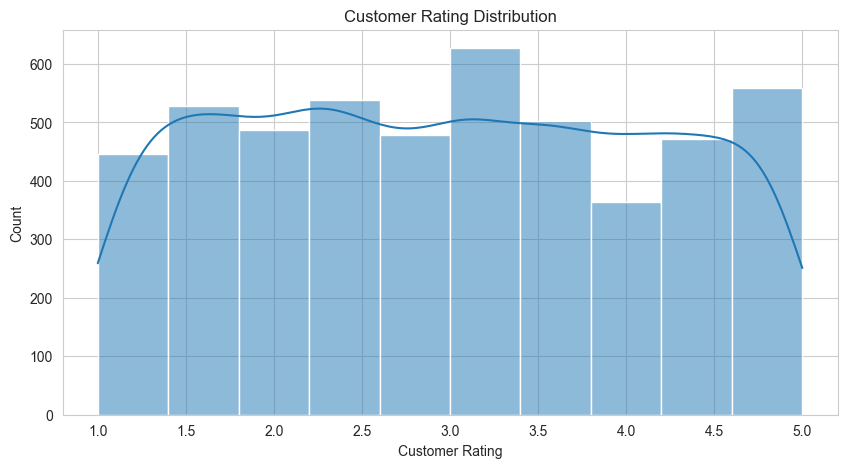

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['customer_rating'],
    bins=10,
    kde=True
)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")

plt.show()


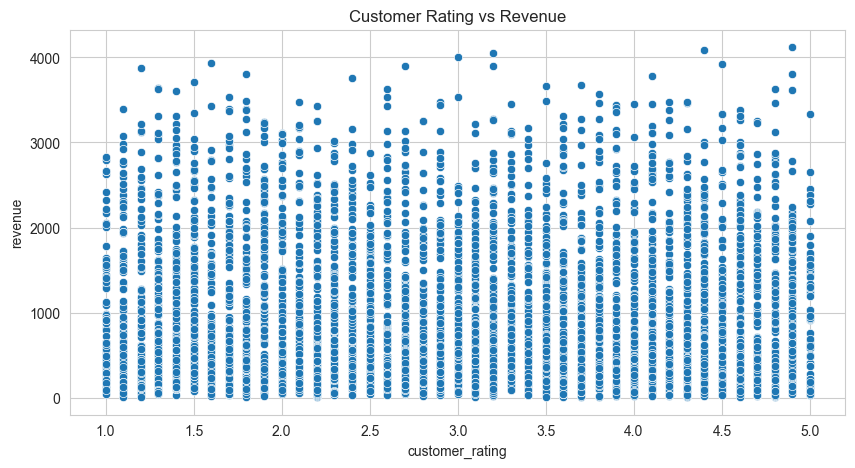

In [24]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='customer_rating',
    y='revenue',
    data=df
)

plt.title("Customer Rating vs Revenue")

plt.show()

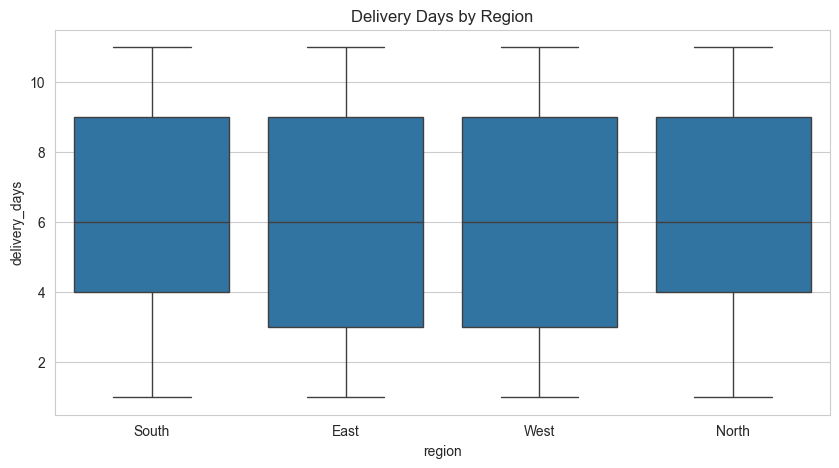

In [25]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='region',
    y='delivery_days',
    data=df
)

plt.title("Delivery Days by Region")

plt.show()

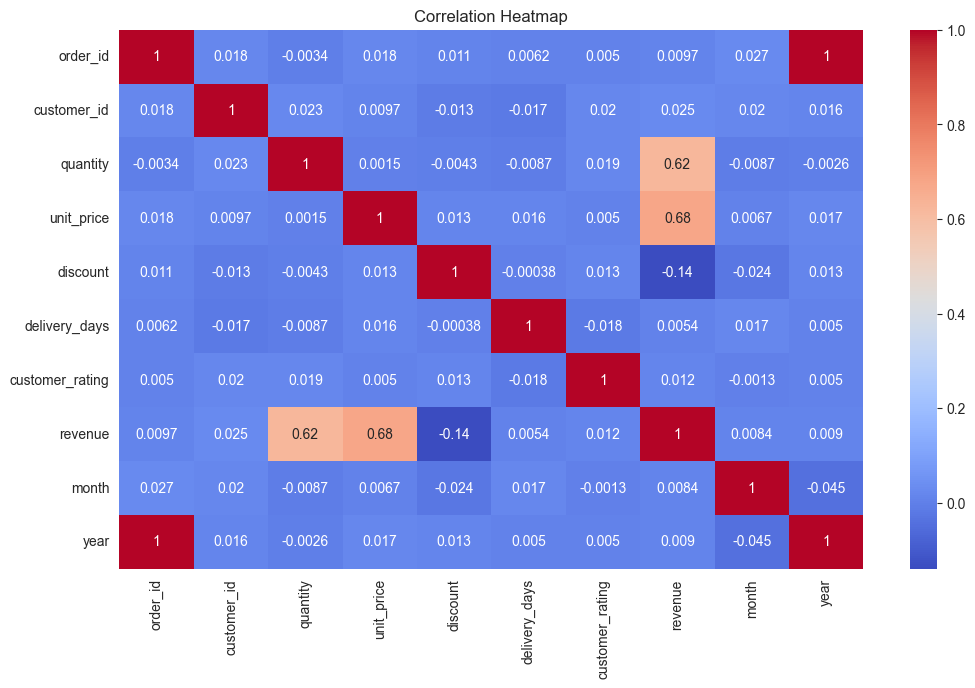

In [26]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

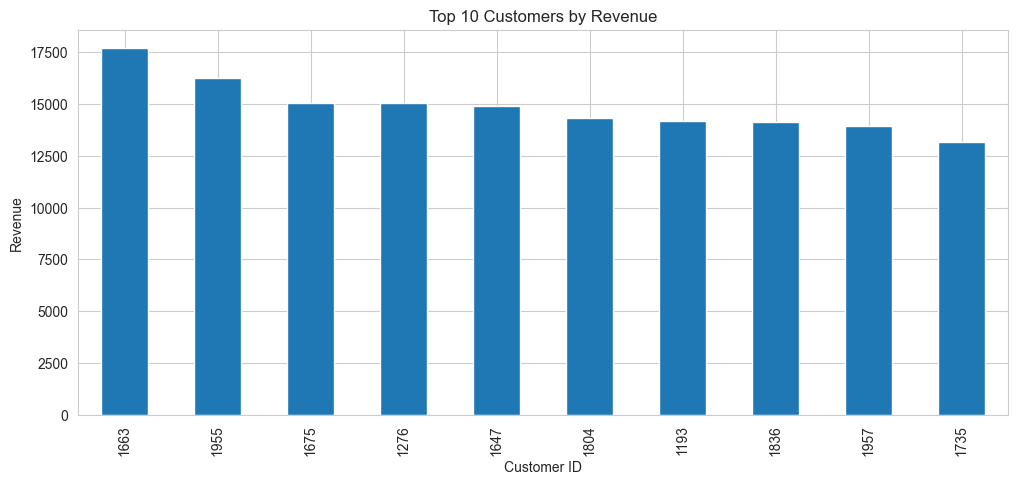

In [27]:
top_customers = df.groupby(
    'customer_id'
)['revenue'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

top_customers.plot(
    kind='bar'
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.show()


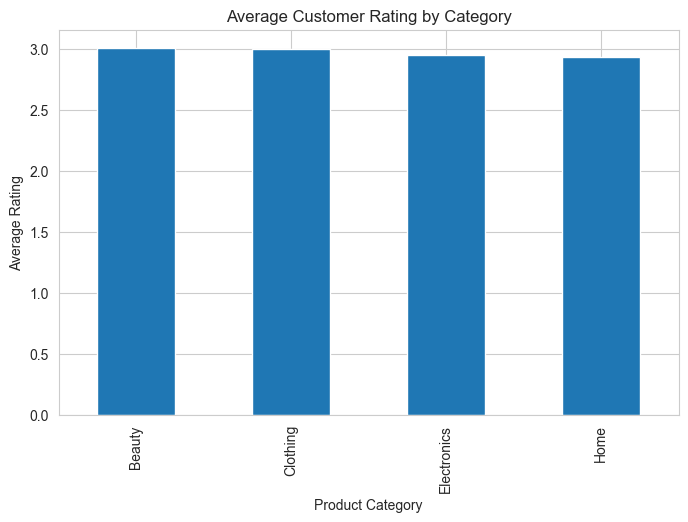

In [30]:
avg_rating = df.groupby(
    'product_category'
)['customer_rating'].mean()

plt.figure(figsize=(8,5))

avg_rating.plot(
    kind='bar'
)

plt.title("Average Customer Rating by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Rating")

plt.show()

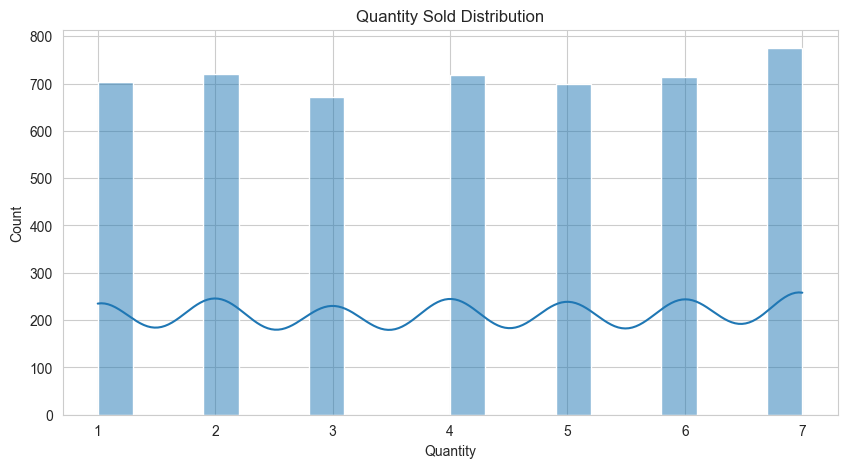

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['quantity'],
    bins=20,
    kde=True
)

plt.title("Quantity Sold Distribution")
plt.xlabel("Quantity")

plt.show()

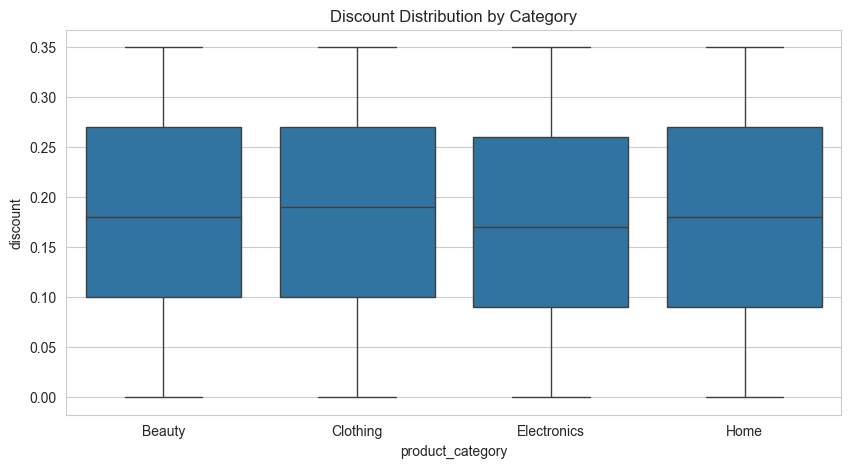

In [32]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='product_category',
    y='discount',
    data=df
)

plt.title("Discount Distribution by Category")

plt.show()